# **ЗАДАНИЕ 2**

В данной работе нужно применить рекуррентные сети к задаче ***предсказания цены акций компании Microsoft***.

В данном блокноте имеется частично готовый к применению код, некоторые элементы которого пропущены и вместо них стоит заглушка "ENTER YOUR CODE HERE". Вместо неё необходимо написать код, решающий конкретную подзадачу. <br> Детали находятся в комментариях около каждого из таких мест.

In [1]:
!pip install numpy matplotlib tensorflow

Для воспроизводимости зафиксируем генераторы случайных чисел.

In [3]:
seed_value = 0

import os
os.environ['PYTHONHASHSEED'] = str(seed_value)

import random
random.seed(seed_value)

import numpy as np
np.random.seed(seed_value)

import tensorflow as tf
tf.random.set_seed(seed_value)

Импортируем все необходимые библиотеки.

In [4]:
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

Для начала нам необходимо прочитать набор данных. Вместе с данным ноутбуком вы найдете файл MSFT_corrupted.csv. Прочитайте и запишите его в фрейм.

In [5]:
df_dirty = pd.read_csv('MSFT_corrupted.csv')

Давайте выведем первые несколько строк файла.

In [6]:
df_dirty.head()

,date,open,high,low,close,volume,Name
0,2015-11-18,53.00,53.98,52.9799,53.85,29710030,MSFT
1,2015-11-19,53.99,54.66,53.7810,53.94,28149228,MSFT
2,2015-11-20,54.25,54.30,53.2650,54.19,37147608,MSFT
3,2015-11-23,54.25,54.46,53.7500,54.19,28235918,MSFT
4,2015-11-24,53.92,54.44,53.5800,54.25,24600043,MSFT


Судя по названию файла, в нем могут присутствовать проблемы с данными. Давайте проверим данные на наличие NaN и каким-либо образом восстановим пропущенные значения.

In [7]:
print(df_dirty.isna().sum())   # Смотрим, есть ли NaN
df = df_dirty.interpolate(method='linear', limit_direction='both')     # Если есть - избавляемся от них.

date      0
open      5
high      5
low       5
close     5
volume    0
Name      0
dtype: int64


/tmp/ipykernel_8991/3871537285.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df_dirty.interpolate(method='linear', limit_direction='both')     # Если есть - избавляемся от них.


В данной работе мы с вами будем предсказывать стоимость акции на момент закрытия дня (колонка 'close'). Давайте построим график этой колонки.

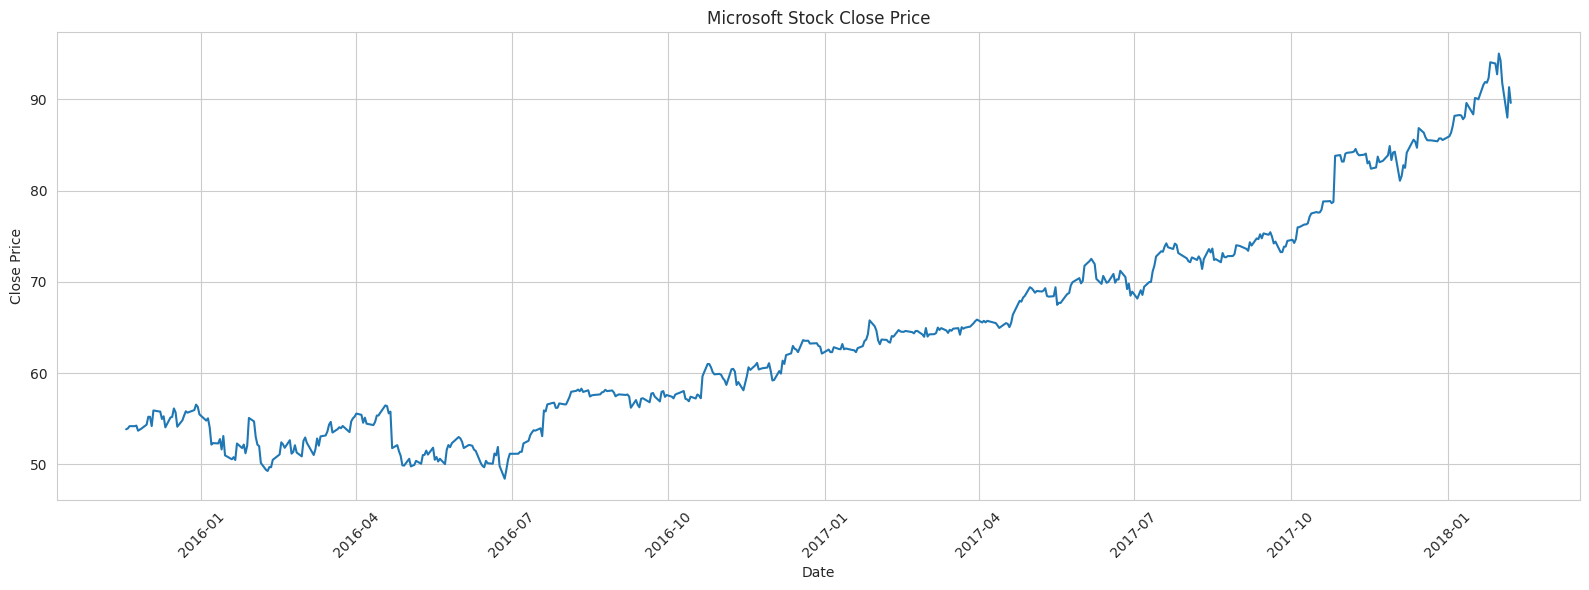

In [12]:
plt.figure(figsize=(16, 6))
plt.plot(df['date'], df['close'])
plt.title('Microsoft Stock Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Оставим в нашем датафрейме только необходимую нам колонку.

In [13]:
train_df = df[['close']].copy()

Итак, теперь давайте подготовим все необходимое для начала обучения. Зададим глобальные константы - количества эпох, дней и коэффициент деления массива.

In [14]:
EPOCHS = 10  # количество эпох для обучения
DAYS = 10    # на сколько дней назад смотреть при обучении
SPLIT_VALUE = 0.95  # как делить массив

Определим константу для разделения массива на тренировочную и тестовую части.

In [15]:
training_data_len = int(len(train_df) * SPLIT_VALUE)
training_data_len

531

Далее с помощью MinMaxScaler'а приведем данные к значениям на отрезке \[0, 1]

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(train_df)

Давайте создадим тренировочный набор данных. Набор будет выглядеть следующим образом: мы будем брать данные за последние X дней и формировать из этого вектор X, а вектор Y будет являться значением стоимости акции на следующий день

In [17]:
train_data = scaled_data[:training_data_len, :]

x_train = []
y_train = []

for i in range(DAYS, len(train_data)):
    x_train.append(train_data[i-DAYS:i])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

Создадим модель для предсказания. Первым слоем модели должен являться рекуррентный слой с соответствующей формой входного тензора, последним - полносвязный слой с единственным нейроном для предсказания результата.

In [18]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=False, input_shape=(DAYS, 1)))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model.fit(x_train, y_train, batch_size=1, epochs=EPOCHS)

Epoch 1/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0031
Epoch 2/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0010
Epoch 3/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 8.8151e-04
Epoch 4/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 7.8597e-04
Epoch 5/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 7.0596e-04
Epoch 6/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.3678e-04
Epoch 7/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.7619e-04
Epoch 8/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.2344e-04
Epoch 9/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.7893e-04
Epoch 10/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.4346e-04


Для тестирования нашей модели давайте таким же образом сформируем тестовый датасет.

In [20]:
test_data = scaled_data[training_data_len - DAYS: , :]

x_test = []
y_test = []
for i in range(DAYS, len(test_data)):
    x_test.append(test_data[i-DAYS:i])
    y_test.append(test_data[i, 0])
# После этого добавьте преобразование в numpy массивы:
x_test, y_test = np.array(x_test), np.array(y_test)

Давайте получим предсказания модели и визуализируем результат.

In [21]:
predictions = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step


/tmp/ipykernel_8991/523100001.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions'] = scaler.inverse_transform(predictions)


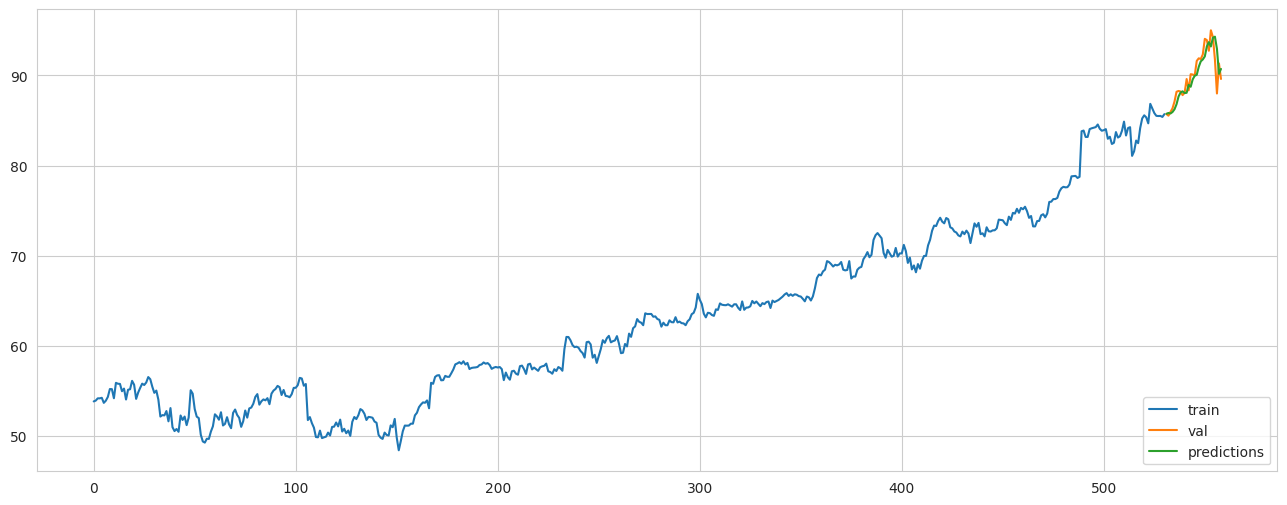

In [22]:
train = train_df[:training_data_len]
valid = train_df[training_data_len:]
valid['predictions'] = scaler.inverse_transform(predictions)
plt.figure(figsize=(16,6))
plt.plot(train['close'])
plt.plot(valid[['close', 'predictions']])
plt.legend(['train', 'val', 'predictions'], loc='lower right')

В качестве бейзлайна (т.е. базовой просто модели для сравнения) выберем step-1 модель. Данная модель для дня i просто берет значение дня i-1. Реализуйте такую модель и в массив prediction_step запишите ее результаты для тех же данных.

In [23]:
predictions_step = []
for i in range(len(x_test)):
    predictions_step.append(x_test[i][-1, 0])
predictions_step = np.array(predictions_step).reshape(-1, 1)

In [24]:
assert predictions.shape == predictions_step.shape

Построим график нашей модели и step-1 модели.

/tmp/ipykernel_8991/1478130906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions_step'] = predictions_step


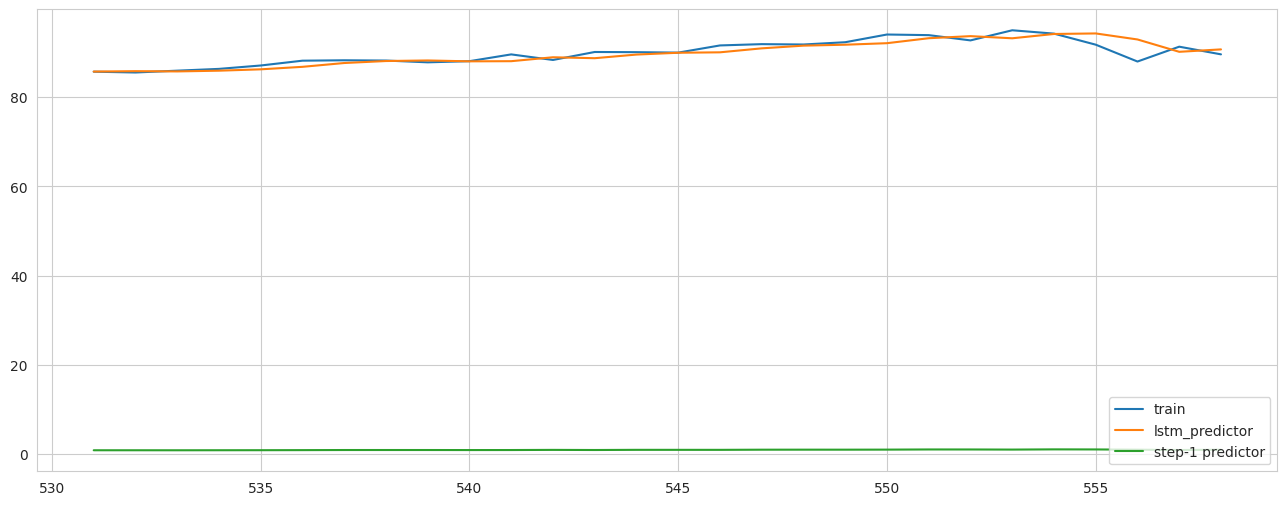

In [25]:
valid['predictions_step'] = predictions_step
plt.figure(figsize=(16,6))
plt.plot(valid[['close', 'predictions', 'predictions_step']])
plt.legend(['train', 'lstm_predictor', 'step-1 predictor'], loc='lower right')

Удалось ли вам добиться хороших результатов модели? Попробуйте поменять модель нейронной сети, количество слоев, и другие гиперпараметры.  

В процессе тестирования нашей модели мы, тем не менее, использовали "настоящие" данные каждый день для предсказания следующего дня. Давайте попробуем предсказать `len(valid)` дней (т.е. столько же, какова длина массива тестирования) обладая лишь данными на момент дня начала тестирования.  

Т.е. каждый шаг алгоритму необходимо подавать данные за последние DAYS дней, получать его предсказание и записывать в массив с данными как результат дня $i$. На следующем шаге в качестве данных уже будут данные за последние DAYS-1 дней и день $i$, а результат будет записан в день $i+1$ и так далее. Конечным итогом станет то, что мы сможем предсказать движение акций на несколько дней вперед.

In [26]:
x_test_independent = scaled_data[-DAYS:].copy()   # взять данные за первый день тестового периода
for i in range(len(valid)):
    result = model.predict(x_test_independent[-DAYS:].reshape(1, DAYS, 1), verbose=0)    # Получить предсказание модели на данных
    # Обновление массива
    x_test_independent = np.append(x_test_independent, result, axis=0)  # Добавить полученный result в конец массива x_test_independent, т.о. он будет использован в следующий раз

Давайте построим график и посмотрим на результат, а также сравним его с результатом, когда нам известна настоящая информация за указанные дни.

/tmp/ipykernel_8991/2114470076.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions_indep'] = scaler.inverse_transform(x_test_independent.reshape((-1, 1)))[-len(valid):]


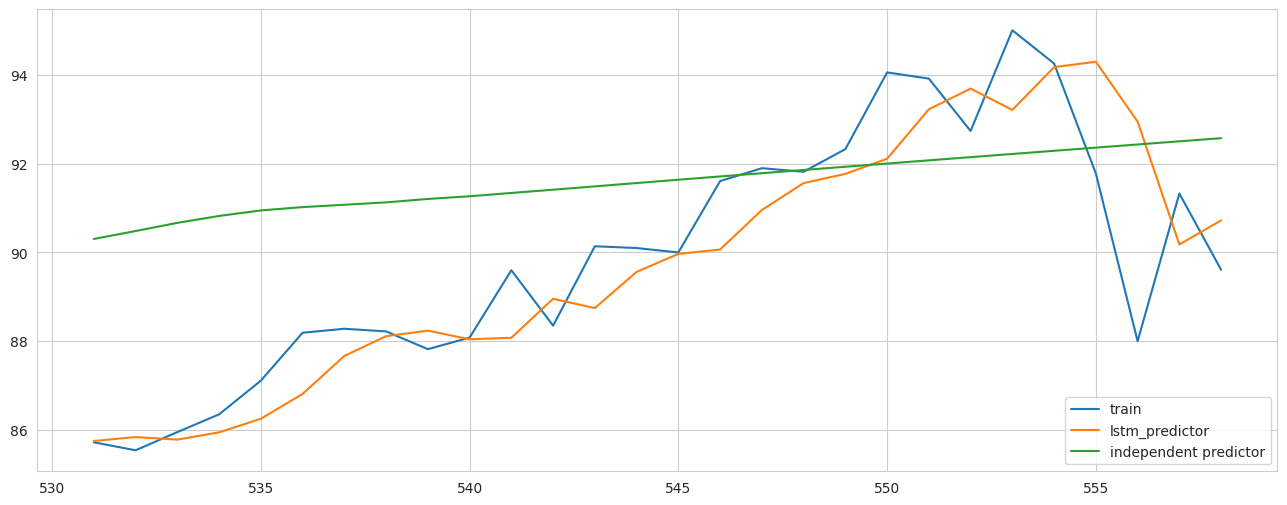

In [27]:
valid['predictions_indep'] = scaler.inverse_transform(x_test_independent.reshape((-1, 1)))[-len(valid):]
plt.figure(figsize=(16,6))
plt.plot(valid[['close', 'predictions', 'predictions_indep']])
plt.legend(['train', 'lstm_predictor', 'independent predictor'], loc='lower right')

Как можно заметить, результат оставляет желать лучшего. Рекуррентные модели склонны не учитывать тренд и фиксироваться на какой-либо точке.  

Вашим дальнейшим заданием будет следующее.  
В процессе анализа стоимости акций важным параметром является Moving Average - средняя стоимость акций за последние N дней. Вам необходимо вычислить MA за последние 7, 14 и 28 дней и добавить их как отдельные столбцы к тренировочным данным. После чего - натренировать новую нейронную сеть, которая будет получать MA 7, 14, 28 как входные данные и пытаться предсказывать их значения.

В конце точно так же сравните полученный результат с step-1 моделью и попробуйте построить предсказания из единственной точки. Сможет ли Moving Average исправить проблемы тренда за счет более гладких и усредненных результатов?

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


495/495 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0029
Epoch 2/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.4227e-04
Epoch 3/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.6864e-04
Epoch 4/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.0625e-04
Epoch 5/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.5855e-04
Epoch 6/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.2253e-04
Epoch 7/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.9372e-04
Epoch 8/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.7145e-04
Epoch 9/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5295e-04
Epoch 10/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.3636e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


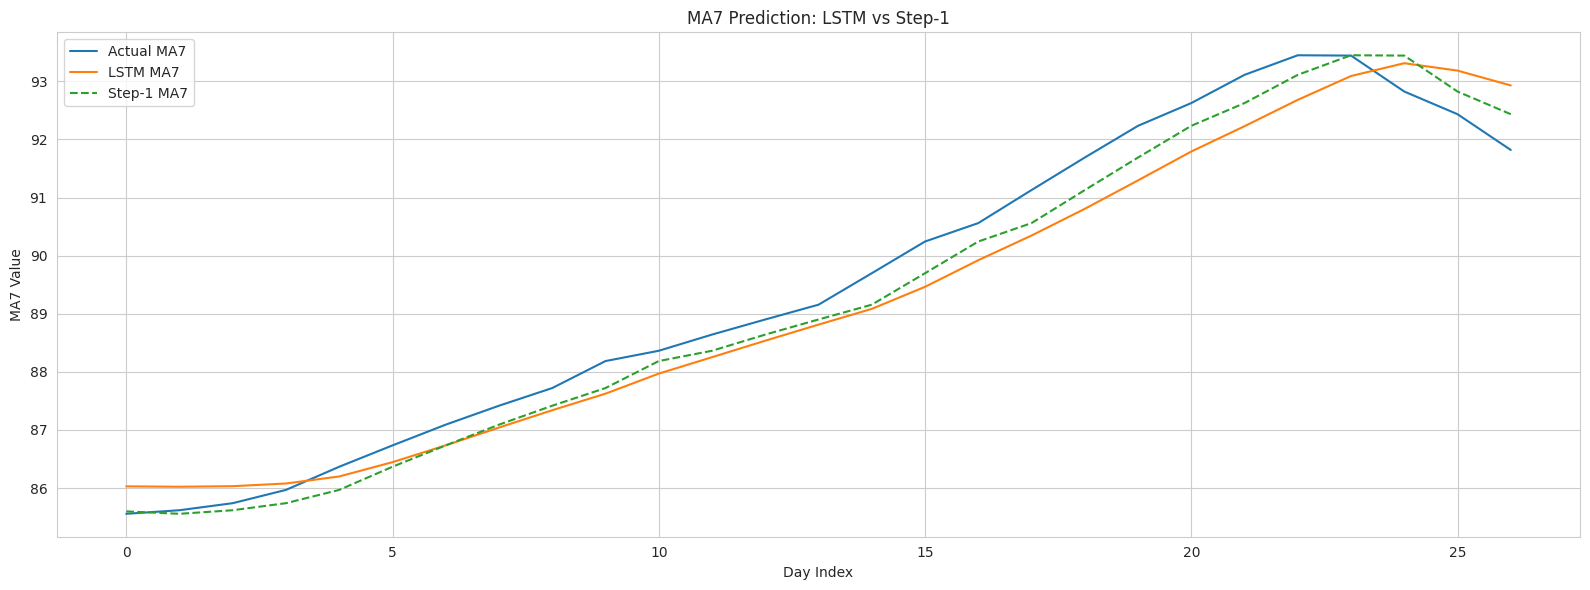

In [28]:
# Вычисляем Moving Average
df_ma = df[['date', 'close']].copy()
df_ma['MA7'] = df_ma['close'].rolling(window=7).mean()
df_ma['MA14'] = df_ma['close'].rolling(window=14).mean()
df_ma['MA28'] = df_ma['close'].rolling(window=28).mean()
df_ma = df_ma.dropna().reset_index(drop=True)

# Подготовка данных для MA
ma_cols = ['MA7', 'MA14', 'MA28']
scaler_ma = MinMaxScaler(feature_range=(0, 1))
scaled_ma = scaler_ma.fit_transform(df_ma[ma_cols])

train_len_ma = int(len(scaled_ma) * SPLIT_VALUE)
train_ma = scaled_ma[:train_len_ma]
test_ma = scaled_ma[train_len_ma - DAYS:]

x_train_ma, y_train_ma = [], []
for i in range(DAYS, len(train_ma)):
    x_train_ma.append(train_ma[i-DAYS:i])
    y_train_ma.append(train_ma[i])
x_train_ma, y_train_ma = np.array(x_train_ma), np.array(y_train_ma)

x_test_ma, y_test_ma = [], []
for i in range(DAYS, len(test_ma)):
    x_test_ma.append(test_ma[i-DAYS:i])
    y_test_ma.append(test_ma[i])
x_test_ma, y_test_ma = np.array(x_test_ma), np.array(y_test_ma)

# Модель для предсказания MA
model_ma = Sequential()
model_ma.add(LSTM(50, return_sequences=False, input_shape=(DAYS, 3)))
model_ma.add(Dense(3))  # 3 выхода: MA7, MA14, MA28
model_ma.compile(optimizer='adam', loss='mse')
model_ma.fit(x_train_ma, y_train_ma, epochs=EPOCHS, batch_size=1, verbose=1)

# Предсказания и Step-1 baseline для MA
pred_ma = model_ma.predict(x_test_ma)
pred_ma_inv = scaler_ma.inverse_transform(pred_ma)
actual_ma_inv = scaler_ma.inverse_transform(y_test_ma)

# Step-1 для MA
pred_ma_step = np.array([x_test_ma[i][-1] for i in range(len(x_test_ma))])
pred_ma_step_inv = scaler_ma.inverse_transform(pred_ma_step)

# Визуализация (на примере MA7)
plt.figure(figsize=(16, 6))
plt.plot(actual_ma_inv[:, 0], label='Actual MA7')
plt.plot(pred_ma_inv[:, 0], label='LSTM MA7')
plt.plot(pred_ma_step_inv[:, 0], label='Step-1 MA7', linestyle='--')
plt.title('MA7 Prediction: LSTM vs Step-1')
plt.xlabel('Day Index')
plt.ylabel('MA7 Value')
plt.legend()
plt.tight_layout()
plt.show()